This Code mostly handles Input Signal Decomposition only!!


Import Necessary Modules


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import os

Design the class ContinuousSignal


In [55]:
class ContinuousSignal:
    def __init__(self, func): # funtion pointer for the continuos signal
        self.func=func
    def shift(self, t0): # returns new signal with time shifting
        return ContinuousSignal(lambda t: self.func(np.array(t)-t0))
    def multiply_const_factor(self, f):
        return ContinuousSignal(lambda t: f*self.func(np.array(t)))
    def add(self, other):
        return ContinuousSignal(lambda t: self.func(np.array(t))+ other.func(np.array(t)))
    def plot(self, t_min=-3, t_max=3, num_points=1000, title=""):
        t=np.linspace(t_min,t_max,num_points)
        x=self.func(t)
        plt.title(title)
        plt.xlabel("t (time)")
        plt.ylabel("x(t)")
        plt.plot(t,x)

Design class LTI_Continuous


In [56]:
class LTI_Continuous:
    def __init__(self, impulse_response):
        self.impulse_response=impulse_response
    def linear_combination_of_impulses(self, input_signal, delta, t_min, t_max):
        #decomposes input signal into rectangular impulses of height 1/delta and width delta
        impulses=[] #array of continuous signals
        coefficients=[] #array of integers

        #determine timesteps based on delta
        tk_values=np.arange(t_min,t_max, delta)

        #definition of rectangular impulse function: delta width and 1/delta height
        def rect_impulse_func(t):
            return np.where((t>=0) & (t<delta),1.00/delta,0.00)

        for tk in tk_values:
            
            #shifted impulse fuction delta_delta_k(t-tk)
            imp_k=ContinuousSignal(rect_impulse_func).shift(tk)

            #Coefficient ck= input_signal(tk)*delta
            ck= input_signal.func(np.array([tk]))[0]*delta
            
            impulses.append(imp_k)
            coefficients.append(ck)
        return impulses,coefficients


In [57]:
def main():
    # Setup parameters
    T=3
    delta=0.2

    #define x(t)=e^(-t)u(t)
    def x_func(t):
        return np.exp(-t)*(t>=0)
    
    input_signal=ContinuousSignal(x_func)
    
    #define a response for the LTI_System.... for now it doesn't affect our work
    def h_func(t):
        return np.astype((t>=0),float)

    #Now declare the LTI system
    system=LTI_Continuous(h_func)

    #get the impulse and the coefficients
    impulses, coefficients= system.linear_combination_of_impulses(input_signal,delta,-3,+3)

    #reconstruct the staircase decomposition of the input signal....
    reconstructed=None

    for imp,ck in zip(impulses,coefficients):
        component=imp.multiply_const_factor(ck)
        if reconstructed is None:
            reconstructed =component
        else:
            reconstructed=reconstructed.add(component)
    
    input_signal.plot()
    reconstructed.plot()

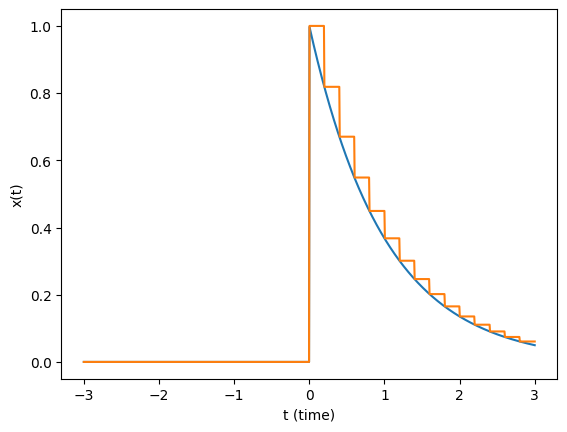

In [58]:
main()